In [1]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
url="https://raw.githubusercontent.com/MohitKumarPandey/Used-Car-Price-Prediction/main/used_car_price_dataset_extended.csv"
df=pd.read_csv(url)
df

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1996,15.25,1500,Petrol,2,5498.71,Hyundai,Manual,Silver,NaN,0,Yes
9996,1997,14.45,5000,Diesel,1,9588.31,Honda,Manual,Gray,Full,0,Yes
9997,2002,19.41,1000,Diesel,4,4557.10,Kia,Manual,Black,Full,0,Yes
9998,2005,12.95,4000,Petrol,5,7413.59,BMW,Automatic,Blue,Full,0,Yes


In [3]:
# handling missing values 
df.isnull().sum()


make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

In [4]:
df.dropna(inplace=True)
print(df["insurance_valid"].unique())
print(df["service_history"].unique())

<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['Full', 'Partial']
Length: 2, dtype: str


In [5]:
cols = ["fuel_type","brand", "transmission", "color", "service_history", "insurance_valid"]

df[cols] = df[cols].apply(lambda x: x.str.lower())
df

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
2,2023,18.09,2500,diesel,5,9273.58,bmw,automatic,black,full,1,yes
3,2009,11.28,800,petrol,1,6836.24,hyundai,manual,blue,full,0,yes
4,2005,12.23,1000,petrol,2,4625.79,nissan,automatic,red,full,0,yes
5,2002,13.77,2500,diesel,4,6856.03,bmw,manual,gray,full,1,yes
6,2023,12.50,1000,petrol,3,6806.77,bmw,manual,red,full,0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...
9994,2014,16.57,5000,petrol,2,11527.42,volkswagen,manual,silver,full,0,yes
9996,1997,14.45,5000,diesel,1,9588.31,honda,manual,gray,full,0,yes
9997,2002,19.41,1000,diesel,4,4557.10,kia,manual,black,full,0,yes
9998,2005,12.95,4000,petrol,5,7413.59,bmw,automatic,blue,full,0,yes


In [6]:
# # encoding of data
# # for col in ['fuel_type','brand','transmission','color']:
# #     df[col]=label.fit_transform(df[col])
fuel_encoder=LabelEncoder()
brand_encoder=LabelEncoder()
transmission_encoder=LabelEncoder()
color_encoder=LabelEncoder()
service_encoder=LabelEncoder()
insurance_encoder=LabelEncoder()
df['fuel_type']=fuel_encoder.fit_transform(df['fuel_type'])
df['brand']=brand_encoder.fit_transform(df['brand'])
df['transmission']=transmission_encoder.fit_transform(df['transmission'])
df['color']=color_encoder.fit_transform(df['color'])
df['insurance_valid']=insurance_encoder.fit_transform(df['insurance_valid'])
df['service_history']=service_encoder.fit_transform(df['service_history'])


In [7]:
 # splitting of data 
X=df[['make_year','mileage_kmpl','engine_cc','fuel_type','owner_count','brand','transmission','color','service_history','accidents_reported','insurance_valid']]
y=df['price_usd']

# train split and test 
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [13]:
# model train 
model=LinearRegression()
model.fit(x_train,y_train)

# model prediction 
make_year=int(input("enter the making year of vechile"))
mileage=float(input("enter the mileage of vechile in kmpl"))
engineCC=int(input("enter the engine CC"))
fuel=input("enter the fuel type of vechile").lower()
owner_count=int(input("enter the total number of owner of the vechile"))
brand = input(
    "Enter brand name --> ['chevrolet', 'honda', 'bmw', 'hyundai', 'nissan', 'tesla', 'toyota', 'kia', 'volkswagen', 'ford']: "
).lower()
transmission=input("enter the transmission type --> Manual or Automatic").lower()
color=input("enter the color of the vechile  --> black,blue,silver,white,grey").lower()
service_history=input("enter the service history of the vechile --> Full or Partial ").lower()
accidents_Report=int(input("enter the accident number of the vechile"))
insurance_valid=input("insurance is valid or not valid choose Yes or No").lower()

fuel=fuel_encoder.transform([fuel])
brand=brand_encoder.transform([brand])
transmission=transmission_encoder.transform([transmission])
color=color_encoder.transform([color])
service_history=service_encoder.transform([service_history])
insurance_valid=insurance_encoder.transform([insurance_valid])
new_data = pd.DataFrame({
    "make_year": [make_year],
    "mileage_kmpl": [mileage],
    "engine_cc": [engineCC],
    "fuel_type": [fuel[0]],
    "owner_count": [owner_count],
    "brand": [brand[0]],
    "transmission": [transmission[0]],
    "color": [color[0]],
    "service_history": [service_history[0]],
    "accidents_reported": [accidents_Report],
    "insurance_valid": [insurance_valid[0]]
})
# model prediction 
predict_price=model.predict(new_data)
print("predicted price=",predict_price[0])

enter the making year of vechile 2023
enter the mileage of vechile in kmpl 18.09
enter the engine CC 2500
enter the fuel type of vechile diesel
enter the total number of owner of the vechile 1
Enter brand name --> ['chevrolet', 'honda', 'bmw', 'hyundai', 'nissan', 'tesla', 'toyota', 'kia', 'volkswagen', 'ford']:  honda
enter the transmission type --> Manual or Automatic manual
enter the color of the vechile  --> black,blue,silver,white,grey blue
enter the service history of the vechile --> Full or Partial  full
enter the accident number of the vechile 1
insurance is valid or not valid choose Yes or No no


predicted price= 10567.418188869255


<Axes: xlabel='engine_cc', ylabel='price_usd'>

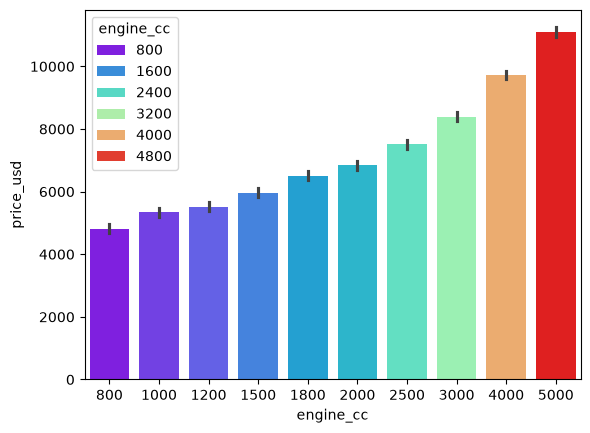

In [9]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.barplot(x=df['engine_cc'],y=df['price_usd'],hue=df['engine_cc'],palette='rainbow')

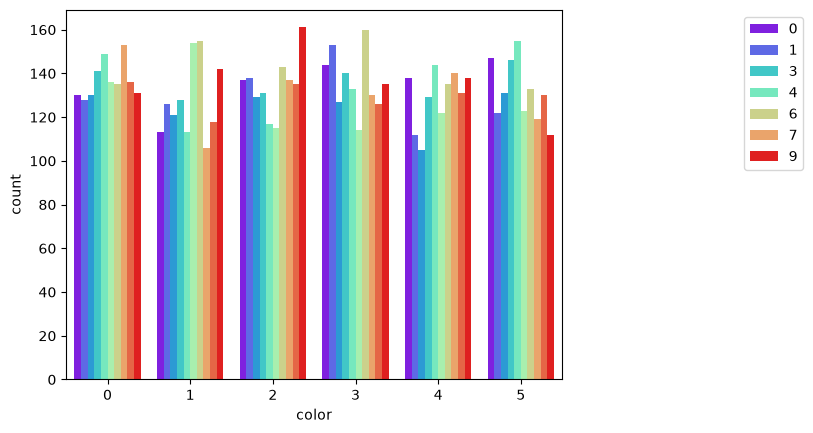

In [10]:
sns.countplot(hue=df['brand'],x=df['color'],palette='rainbow')
plt.legend(bbox_to_anchor=(1.5,1),loc='upper right')

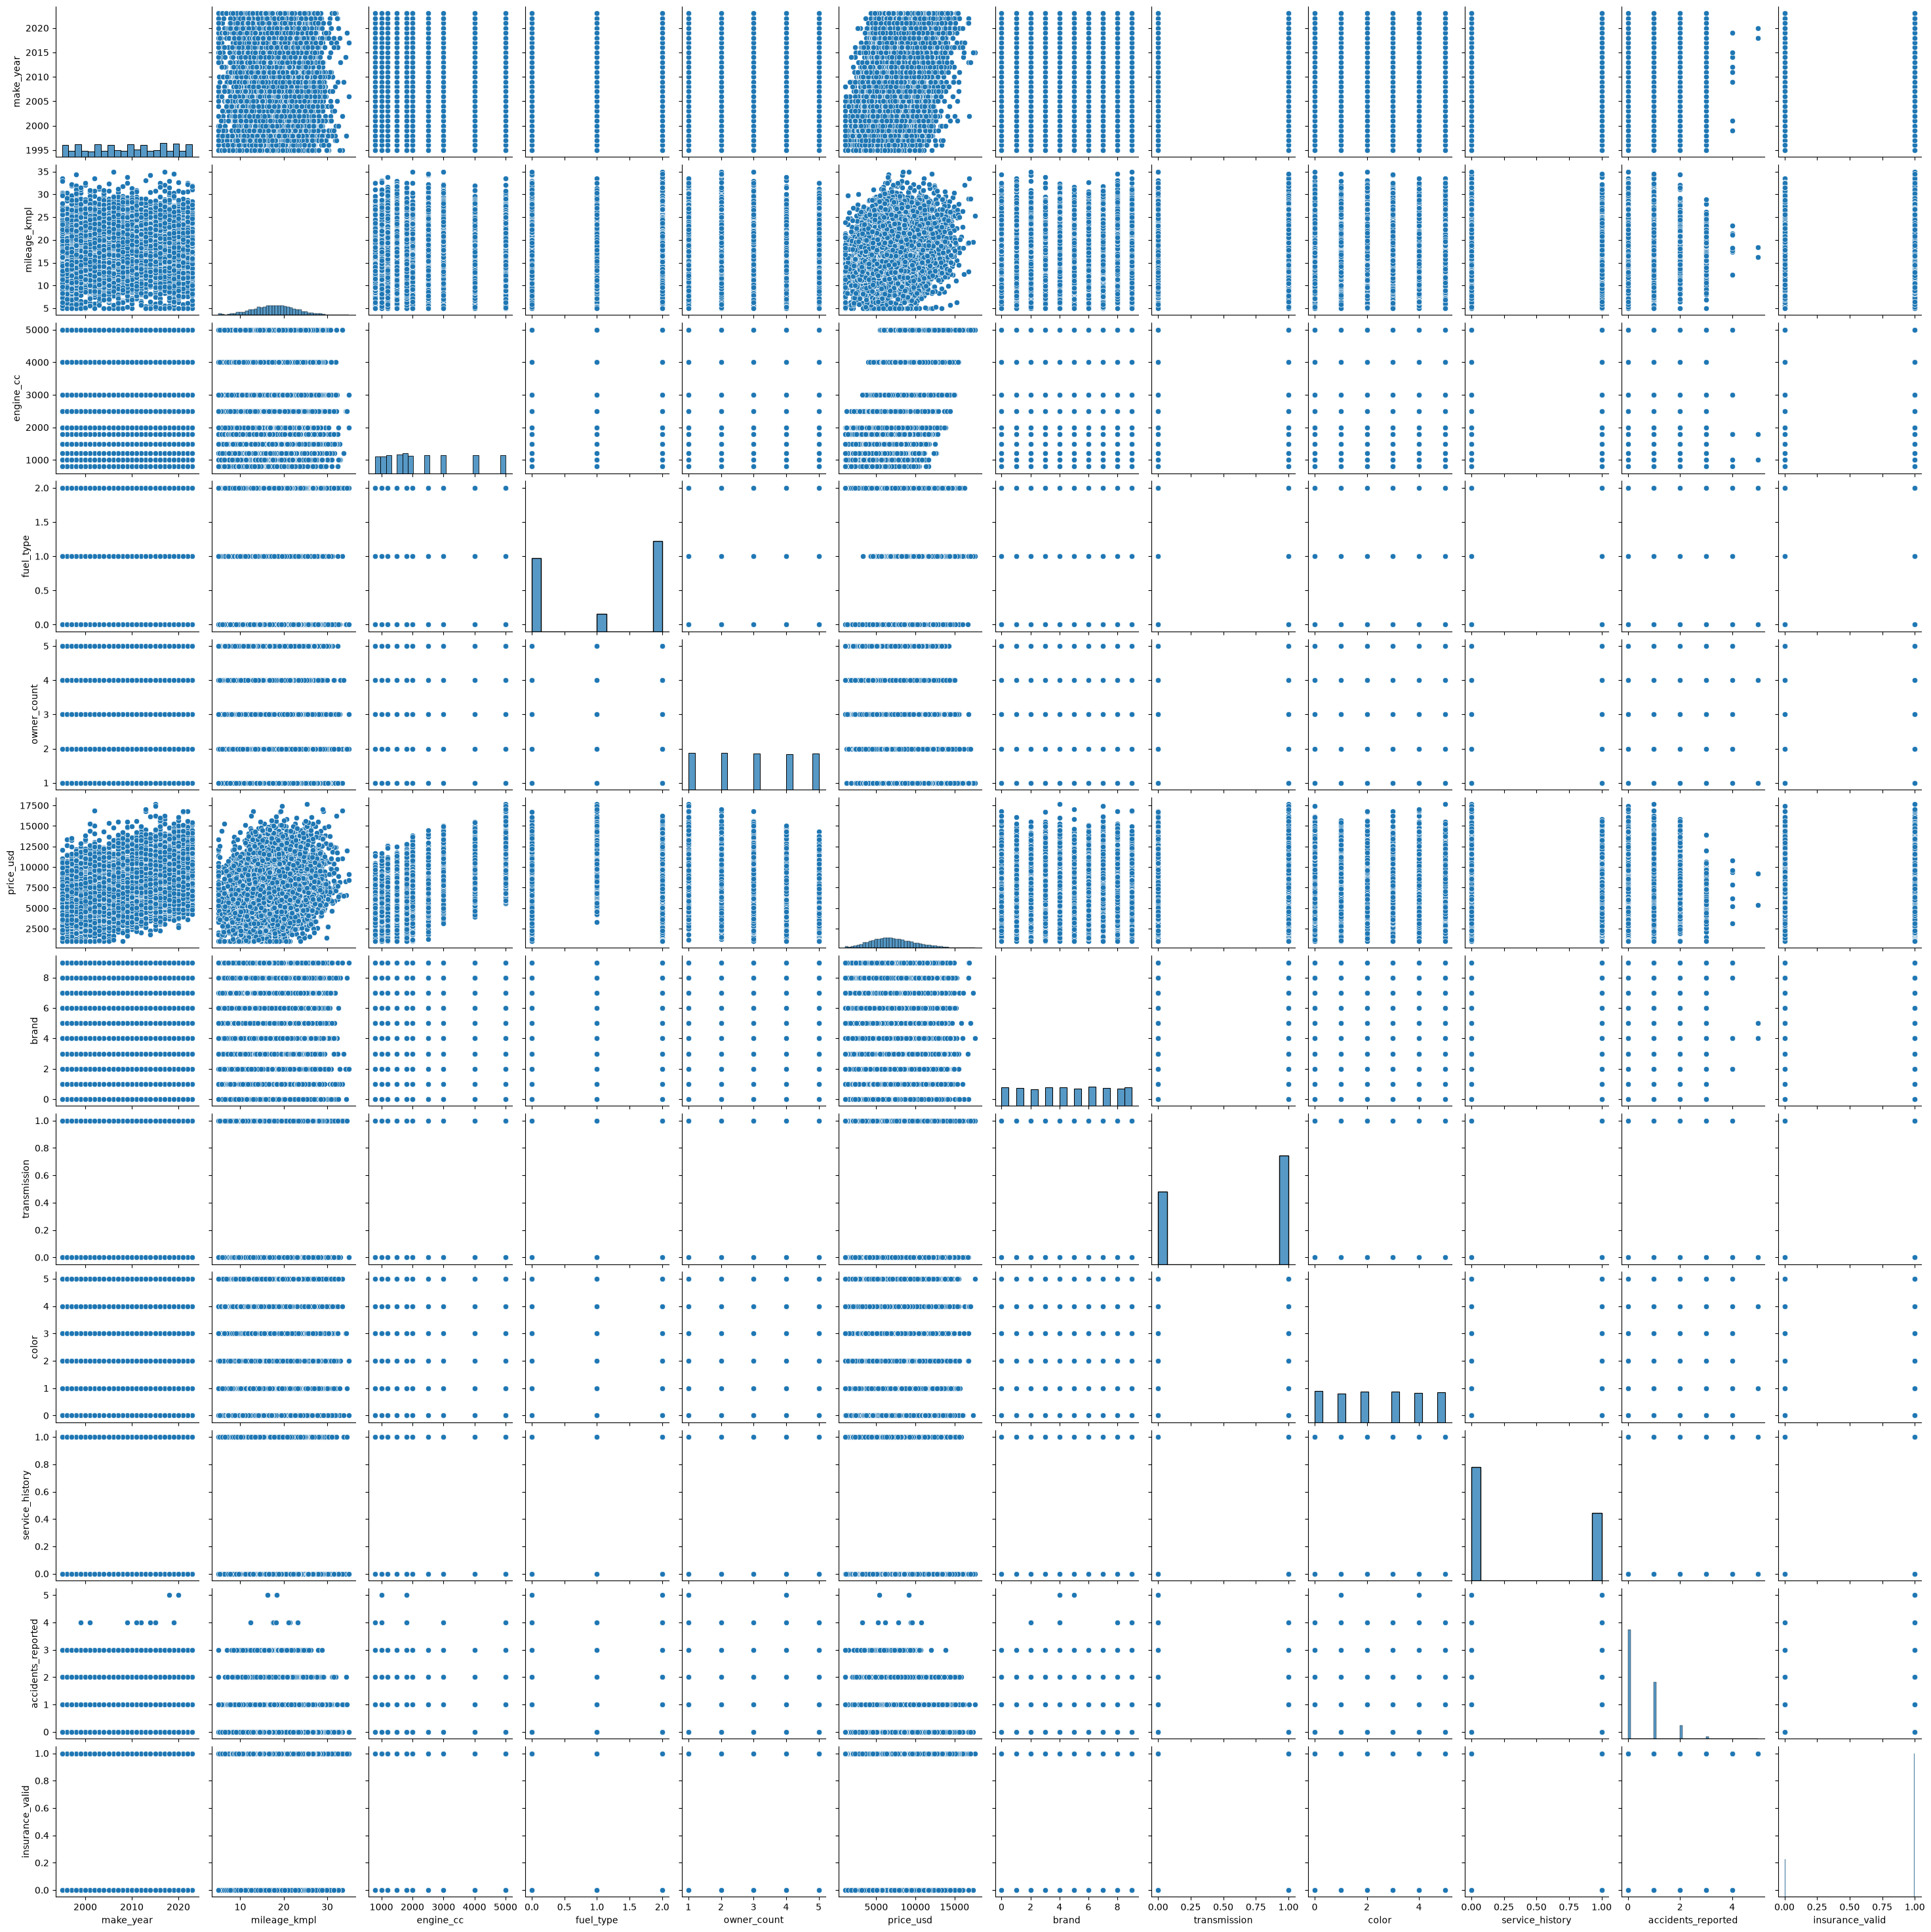

In [16]:
sns.pairplot(df)

In [12]:
# saving the model
import joblib
joblib.dump(model,"usedCarPredictionModel")

['usedCarPredictionModel']